# **gensim 라이브러리의 LDA 실습**

*   토픽 분포간 거리 그래프 시각화 가능
*   사이킷런 라이브러리의 LDA와 결과가 다르므로, 더 해석이 용이한 결과 활용



# 주의) 아래 gensim설치로 인해 세션 다시시작 필요할 수 있음

In [ ]:
!pip install gensim

In [22]:
!pip install pyLDAvis

In [23]:
import pandas as pd
import re
import nltk
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation

import gensim
from gensim import corpora

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


## 1. 파일 다운로드
1. 학교 학술정보관 로그인: https://lib.skku.edu/#/
2. 자료 탭>Database 탭 이동
3. Web of Science 이동
4. 키워드 검색
5.  Export 토글 클릭 후, Content 토글에서 abstract 포함해서 Excel로 내보내기

`샘플 파일`

:ESG 키워드의 High Cited Papers

https://github.com/WooYoungSeok/Topic_Modeling_Practice/blob/0d4e7c853da4c289fdefd56084d21b08dd83b433/ESG_Web_of_Science.xls


- 다운로드 방법
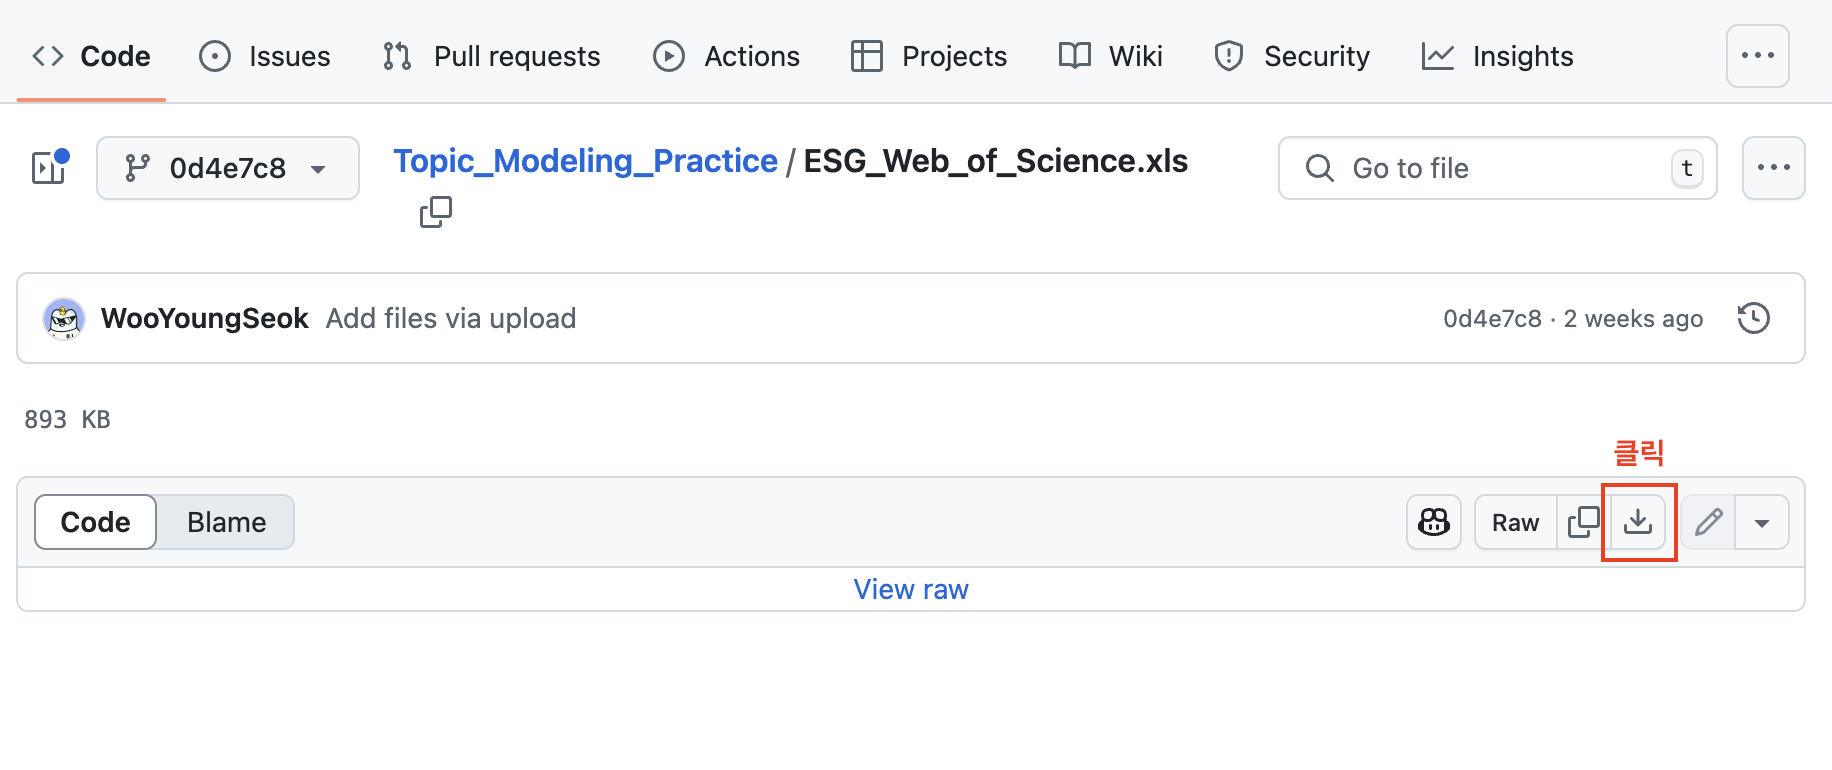


In [3]:
data = pd.read_excel('ESG_Web_of_Science.xls')
print('논문 개수 :',len(data))

논문 개수 : 302


In [4]:
# 데이터 확인
data.head(5)

,Publication Type,Authors,Book Authors,Book Editors,Book Group Authors,Author Full Names,Book Author Full Names,Group Authors,Article Title,Source Title,...,Web of Science Index,Research Areas,IDS Number,Pubmed Id,Open Access Designations,Highly Cited Status,Hot Paper Status,Date of Export,UT (Unique WOS ID),Web of Science Record
0,J,"Schiemann, F; Tietmeyer, R",NaN,NaN,NaN,"Schiemann, Frank; Tietmeyer, Raphael",NaN,NaN,"ESG Controversies, ESG Disclosure and Analyst ...",INTERNATIONAL REVIEW OF FINANCIAL ANALYSIS,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,WOS:000868950000002,0
1,J,"Serafeim, G; Yoon, A",NaN,NaN,NaN,"Serafeim, George; Yoon, Aaron",NaN,NaN,Stock price reactions to ESG news: the role of...,REVIEW OF ACCOUNTING STUDIES,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,WOS:000767004200001,0
2,J,"Asif, M; Searcy, C; Castka, P",NaN,NaN,NaN,"Asif, Muhammad; Searcy, Cory; Castka, Pavel",NaN,NaN,ESG and Industry 5.0: The role of technologies...,TECHNOLOGICAL FORECASTING AND SOCIAL CHANGE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,WOS:001074018000001,0
3,J,"Lopez-de-Silanes, F; McCahery, JA; Pudschedl, PC",NaN,NaN,NaN,"Lopez-de-Silanes, Florencio; McCahery, Joseph ...",NaN,NaN,Institutional Investors and ESG Preferences,CORPORATE GOVERNANCE-AN INTERNATIONAL REVIEW,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,WOS:001202354000001,0
4,J,"Chen, ZF; Xie, GX",NaN,NaN,NaN,"Chen, Zhongfei; Xie, Guanxia",NaN,NaN,ESG disclosure and financial performance: Mode...,INTERNATIONAL REVIEW OF FINANCIAL ANALYSIS,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,WOS:000862664200013,0


In [5]:
# 열 이름 출력
data.columns

Index(['Publication Type', 'Authors', 'Book Authors', 'Book Editors',
       'Book Group Authors', 'Author Full Names', 'Book Author Full Names',
       'Group Authors', 'Article Title', 'Source Title', 'Book Series Title',
       'Book Series Subtitle', 'Language', 'Document Type', 'Conference Title',
       'Conference Date', 'Conference Location', 'Conference Sponsor',
       'Conference Host', 'Author Keywords', 'Keywords Plus', 'Abstract',
       'Addresses', 'Affiliations', 'Reprint Addresses', 'Email Addresses',
       'Researcher Ids', 'ORCIDs', 'Funding Orgs', 'Funding Name Preferred',
       'Funding Text', 'Cited References', 'Cited Reference Count',
       'Times Cited, WoS Core', 'Times Cited, All Databases',
       '180 Day Usage Count', 'Since 2013 Usage Count', 'Publisher',
       'Publisher City', 'Publisher Address', 'ISSN', 'eISSN', 'ISBN',
       'Journal Abbreviation', 'Journal ISO Abbreviation', 'Publication Date',
       'Publication Year', 'Volume', 'Issue', 'Pa

In [6]:
# 'Abstract' 열만 선택하여 새로운 DataFrame에 저장
# 이는 논문의 주제를 요약하기 위해 Abstract 내용만 사용하기 위함입니다.
abstract = data[['Abstract']]
abstract.head(5)

,Abstract
0,We investigate whether an environmental social...
1,"We investigate whether environmental, social, ..."
2,"Environmental, social, and governance (ESG) is..."
3,Research Question/IssueWe examine the effect o...
4,This study discusses the effect of environment...


In [7]:
# 'Abstract' 컬럼의 결측값(NaN)을 제거합니다
abstract = abstract.dropna(subset=['Abstract'])

print('결측값 제거 후 논문 개수 :',len(abstract))

결측값 제거 후 논문 개수 : 301


## 2. 텍스트 전처리

In [8]:
# 이번 실습에서는 불용어 제거(stopword removal), 표제어 추출(lemmatization),
# 그리고 문장부호 제거를 포함한 세 가지 전처리 과정을 수행합니다.

# 각 뉴스 제목(headline_text)에 대해 NLTK의 word_tokenize를 사용하여 토큰화(tokenization)를 수행합니다.
# apply 함수와 lambda식을 사용하여, 각 행(row)에 대해 headline_text 컬럼을 토큰화합니다.
abstract['Abstract'] = abstract.apply(lambda row: nltk.word_tokenize(row['Abstract']), axis=1)

In [9]:
abstract.head(5)

,Abstract
0,"[We, investigate, whether, an, environmental, ..."
1,"[We, investigate, whether, environmental, ,, s..."
2,"[Environmental, ,, social, ,, and, governance,..."
3,"[Research, Question/IssueWe, examine, the, eff..."
4,"[This, study, discusses, the, effect, of, envi..."


In [10]:
# 이제 불용어를 제거합니다.

# NLTK가 제공하는 영어 불용어 리스트를 가져옵니다.
stop_words = stopwords.words('english')

# 각 뉴스 제목(headline_text)에서 불용어에 해당하지 않는 단어만 남깁니다.
abstract['Abstract'] = abstract['Abstract'].apply(
    lambda x: [word for word in x if word not in stop_words]
)

In [11]:
abstract.head(5) # an, and, the 등 제거 됨

,Abstract
0,"[We, investigate, whether, environmental, soci..."
1,"[We, investigate, whether, environmental, ,, s..."
2,"[Environmental, ,, social, ,, governance, (, E..."
3,"[Research, Question/IssueWe, examine, effect, ..."
4,"[This, study, discusses, effect, environmental..."


In [12]:
"""
이제 표제어 추출을 수행합니다. 표제어 추출로 3인칭 단수 표현을 1인칭으로 바꾸고, 과거 현재형 동사를 현재형으로 바꿉니다.
WordNetLemmatizer().lemmatize(word, pos='v')를 사용하여 각 단어에 대해 동사 형태의 표제어 추출을 수행합니다.
"""

abstract['Abstract'] = abstract['Abstract'].apply(lambda x: [WordNetLemmatizer().lemmatize(word, pos='v') for word in x])
abstract.head(5) # 인덱스 4의 discusses -> discuss로 수정됨

,Abstract
0,"[We, investigate, whether, environmental, soci..."
1,"[We, investigate, whether, environmental, ,, s..."
2,"[Environmental, ,, social, ,, governance, (, E..."
3,"[Research, Question/IssueWe, examine, effect, ..."
4,"[This, study, discuss, effect, environmental, ..."


In [13]:
# 문장부호를 제거합니다. 정규 표현식을 사용하여 알파벳이 아닌 모든 문자(공백 포함)를 제거합니다.
# re.sub('[^A-Za-z]', ' ', word)를 사용하여 각 단어에서 알파벳만 남기고 나머지는 공백으로 바꿉니다.
abstract['Abstract'] = abstract['Abstract'].apply(
    lambda x: [re.sub('[^A-Za-z]', ' ', word) for word in x]
)

# 빈 문자열 또는 공백만 있는 문자열이 된 토큰을 제거합니다.
abstract['Abstract'] = abstract['Abstract'].apply(
    lambda x: [word for word in x if len(word.strip()) > 0]
)

abstract.head(5)

,Abstract
0,"[We, investigate, whether, environmental, soci..."
1,"[We, investigate, whether, environmental, soci..."
2,"[Environmental, social, governance, ESG, incre..."
3,"[Research, Question IssueWe, examine, effect, ..."
4,"[This, study, discuss, effect, environmental, ..."


## 3. 정수 인코딩과 단어 집합 만들기

In [17]:
# 이제 각 단어에 정수 인코딩을 수행하고, 각 논문 초록에서의 단어 빈도수를 기록합니다.
# 단어는 (word_id, word_frequency)의 형태로 표현됩니다.
# - word_id: 단어가 정수로 인코딩된 값 (Dictionary에 의해 매핑됨)
# - word_frequency: 해당 논문 초록에서 단어가 등장한 횟수
# 이러한 작업은 gensim의 corpora.Dictionary()를 통해 간단하게 수행할 수 있습니다.

dictionary = corpora.Dictionary(abstract['Abstract']) # 단어 사전 생성
corpus = [dictionary.doc2bow(text) for text in abstract['Abstract']]  # 각 문서의 단어를 (word_id, freq) 형태로 변환
print(corpus[0]) # 첫 번째 문서의 인코딩 결과 출력

[(0, 1), (1, 1), (2, 1), (3, 1), (4, 9), (5, 1), (6, 1), (7, 1), (8, 1), (9, 1), (10, 1), (11, 1), (12, 3), (13, 1), (14, 1), (15, 3), (16, 1), (17, 1), (18, 6), (19, 1), (20, 1), (21, 1), (22, 1), (23, 5), (24, 1), (25, 2), (26, 1), (27, 1), (28, 1), (29, 2), (30, 1), (31, 3), (32, 1), (33, 1), (34, 1), (35, 2), (36, 1), (37, 1), (38, 1), (39, 1), (40, 1), (41, 1), (42, 1), (43, 1), (44, 1), (45, 1), (46, 1), (47, 1), (48, 1), (49, 1), (50, 1), (51, 1), (52, 1), (53, 3), (54, 1), (55, 2), (56, 1), (57, 1), (58, 1), (59, 1), (60, 1), (61, 3), (62, 1)]


In [18]:
# corpus의 각 튜플에서 단어 ID를 얻고, dictionary를 사용하여 실제 단어 확인
# (4,3), (75, 4), (76, 7), (78, 4)

print(dictionary[4]) # ID 4에 해당하는 단어 확인
print(dictionary[75]) # ID 75에 해당하는 단어 확인
print(dictionary[76]) # ID 76에 해당하는 단어 확인
print(dictionary[78]) # ID 78에 해당하는 단어 확인

ESG
market
news
predict


In [26]:
len(dictionary)
# 샘플 파일의 경우: 5056개의 단어 사전이 생성됨

5056

## 4. LDA 모델링 및 시각화

## LDA 모델 훈련시키기


In [27]:
# 토픽 모델링 수행
# NUM_TOPICS: LDA 모델이 추출할 토픽의 개수. 여기서는 3개의 토픽을 설정.
NUM_TOPICS = 3

# gensim.models.ldamodel.LdaModel: LDA 모델을 학습시키는 함수.
# corpus: 학습에 사용할 문서 집합. 각 문서는 (단어 id, 빈도수)의 리스트 형태.
# num_topics: 추출할 토픽의 개수. 위에서 정의한 NUM_TOPICS 사용.
# id2word: 단어 id와 실제 단어를 매핑하는 딕셔너리. corpus를 생성할 때 사용한 dictionary 객체를 사용.
# passes: 훈련 데이터를 반복해서 학습할 횟수. 훈련 횟수가 높을수록 모델의 정확도가 높아지지만, 학습 시간도 오래 걸림. 여기서는 15회로 설정.
ldamodel = gensim.models.ldamodel.LdaModel(corpus, num_topics = NUM_TOPICS, id2word=dictionary, passes=10)

# print_topics: 학습된 LDA 모델에서 각 토픽의 정보를 출력하는 함수.
# num_words: 각 토픽에서 가장 기여도가 높은 단어를 몇 개 출력할지 설정. 여기서는 4개로 설정.
topics = ldamodel.print_topics(num_words=10)

# 추출된 각 토픽과 해당 토픽을 구성하는 주요 단어들을 출력.
for topic in topics:
  print(topic)

(0, '0.035*"ESG" + 0.022*"performance" + 0.015*"green" + 0.012*"firm" + 0.012*"corporate" + 0.010*"environmental" + 0.009*"The" + 0.009*"innovation" + 0.008*"study" + 0.008*"company"')
(1, '0.032*"ESG" + 0.009*"The" + 0.009*"disclosure" + 0.007*"social" + 0.006*"study" + 0.006*"This" + 0.005*"We" + 0.005*"environmental" + 0.005*"firm" + 0.005*"risk"')
(2, '0.020*"ESG" + 0.017*"firm" + 0.008*"study" + 0.008*"risk" + 0.008*"corporate" + 0.007*"We" + 0.007*"effect" + 0.007*"climate" + 0.007*"impact" + 0.007*"performance"')


### LDA 결과 시각화

In [28]:
# LDA 시각화
import pyLDAvis.gensim_models
pyLDAvis.enable_notebook()
vis = pyLDAvis.gensim_models.prepare(ldamodel, corpus, dictionary)
pyLDAvis.display(vis)

### 문서별 토픽 분포 보기

In [29]:
# 각 문서의 토픽 분포 확인
# ldamodel[corpus]는 각 문서에 대해 해당 문서의 토픽 분포를 반환합니다.
# 결과는 각 문서별로 (토픽 id, 해당 토픽에 대한 기여도)의 리스트 형태입니다.
# 예를 들어 [(0, 0.8), (1, 0.2)]는 해당 문서가 토픽 0에 80%, 토픽 1에 20% 기여한다는 의미입니다.
for i, doc_topics in enumerate(ldamodel[corpus]):
  if i==5:
        break
  print(f'문서 {i+1}의 토픽 분포: {doc_topics}')

문서 1의 토픽 분포: [(1, 0.20628478), (2, 0.78967285)]
문서 2의 토픽 분포: [(2, 0.98921436)]
문서 3의 토픽 분포: [(1, 0.99440444)]
문서 4의 토픽 분포: [(1, 0.99474746)]
문서 5의 토픽 분포: [(0, 0.76246107), (1, 0.109215505), (2, 0.12832339)]


In [30]:
# 데이터프레임 형식으로 각 문서의 토픽 분포 출력
def make_topictable_per_doc(ldamodel, corpus):
    topic_rows = []  # 리스트에 각 문서의 정보를 누적

    for i, topic_list in enumerate(ldamodel[corpus]):
        doc = topic_list[0] if ldamodel.per_word_topics else topic_list
        doc = sorted(doc, key=lambda x: (x[1]), reverse=True)

        for j, (topic_num, prop_topic) in enumerate(doc):
            if j == 0:  # 가장 비중 높은 토픽만 저장
                topic_rows.append([i, int(topic_num), round(prop_topic, 4), topic_list])
                break

    # 리스트를 한 번에 데이터프레임으로 변환
    topic_table = pd.DataFrame(topic_rows, columns=['문서 번호', '가장 비중이 높은 토픽', '가장 높은 토픽의 비중', '각 토픽의 비중'])
    return topic_table

In [31]:
# 실행
topictable = make_topictable_per_doc(ldamodel, corpus)
topictable[:10]  # 상위 10개 문서 확인

,문서 번호,가장 비중이 높은 토픽,가장 높은 토픽의 비중,각 토픽의 비중
0,0,2,0.7897,"[(1, 0.2062839), (2, 0.7896737)]"
1,1,2,0.9892,"[(2, 0.9892163)]"
2,2,1,0.9944,"[(1, 0.99440825)]"
3,3,1,0.9947,"[(1, 0.9947484)]"
4,4,0,0.7624,"[(0, 0.7624422), (1, 0.109189674), (2, 0.12836..."
5,5,1,0.9915,"[(1, 0.9915322)]"
6,6,0,0.9893,"[(0, 0.98932225)]"
7,7,2,0.9865,"[(2, 0.9864965)]"
8,8,0,0.9969,"[(0, 0.9969205)]"
9,9,0,0.9908,"[(0, 0.99081546)]"


# **사이킷런의 LDA 사용**


gensim의 LDA와 모델이 달라서 결과도 다름(결과도 다름)

pyLDAv의 시각화는 사용 못함

* 2.데이터 전처리까지는 동일
* gensim 라이브러리를 쓰지 않고, 3.TF-IDF 행렬 만들기



In [32]:
import pandas as pd
import re
import nltk
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


## 1. 파일 다운로드
1. 학교 학술정보관 로그인: https://lib.skku.edu/#/
2. 자료 탭>Database 탭 이동
3. Web of Science 이동
4. 키워드 검색
5.  Export 토글 클릭 후, Content 토글에서 abstract 포함해서 Excel로 내보내기

`샘플 파일`

:ESG 키워드의 High Cited Papers

https://github.com/WooYoungSeok/Topic_Modeling_Practice/blob/0d4e7c853da4c289fdefd56084d21b08dd83b433/ESG_Web_of_Science.xls


- 다운로드 방법
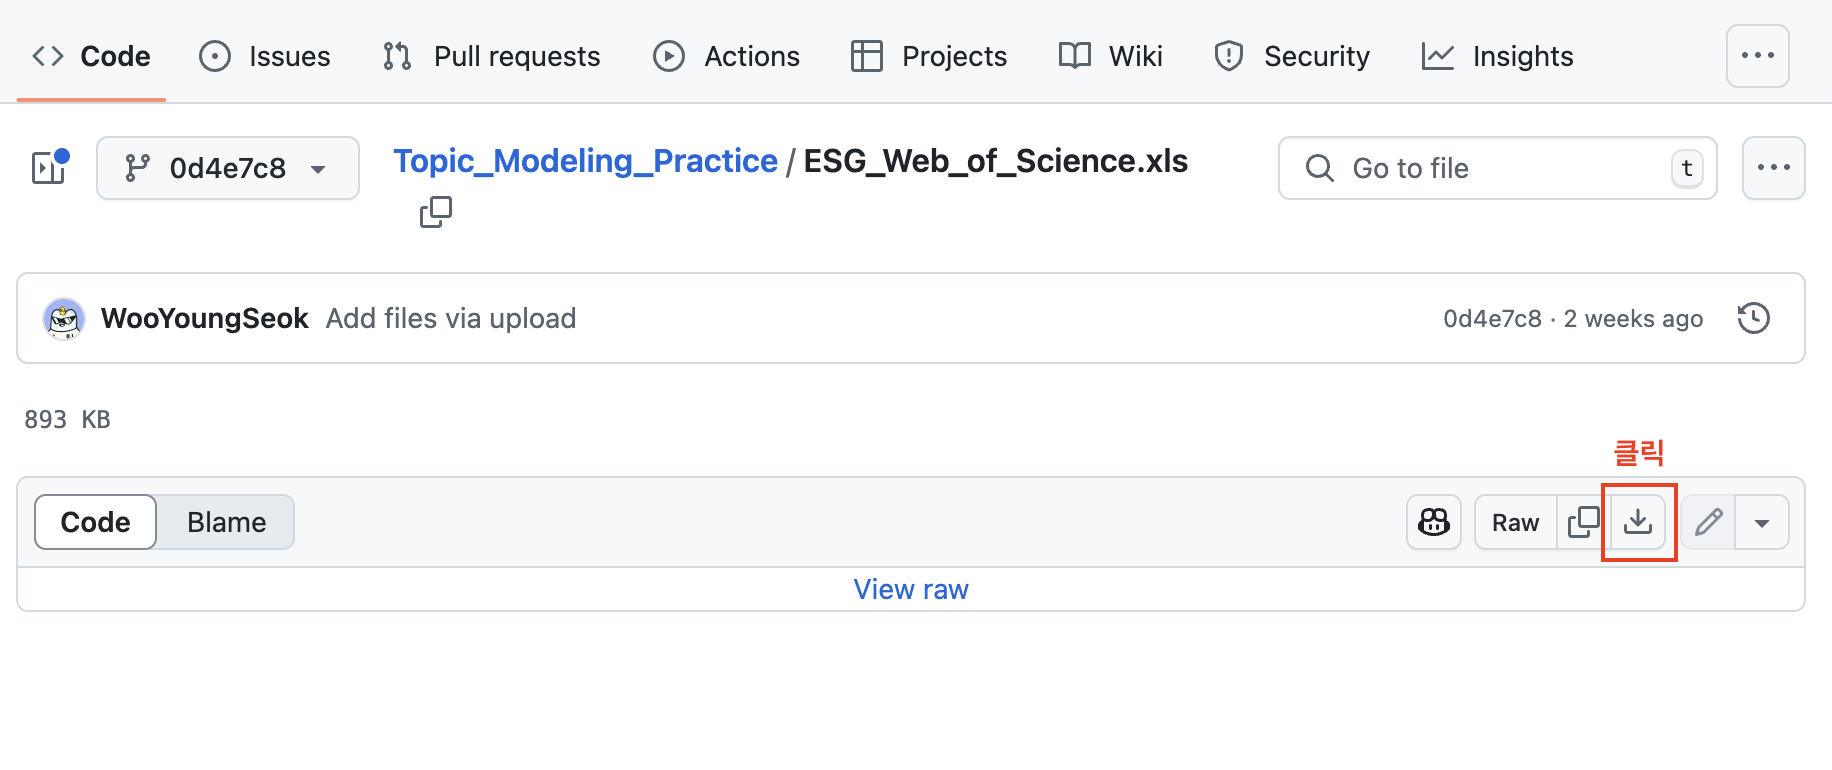


In [33]:
data = pd.read_excel('ESG_Web_of_Science.xls')
print('논문 개수 :',len(data))

논문 개수 : 302


In [34]:
# 데이터 확인
data.head(5)

,Publication Type,Authors,Book Authors,Book Editors,Book Group Authors,Author Full Names,Book Author Full Names,Group Authors,Article Title,Source Title,...,Web of Science Index,Research Areas,IDS Number,Pubmed Id,Open Access Designations,Highly Cited Status,Hot Paper Status,Date of Export,UT (Unique WOS ID),Web of Science Record
0,J,"Schiemann, F; Tietmeyer, R",NaN,NaN,NaN,"Schiemann, Frank; Tietmeyer, Raphael",NaN,NaN,"ESG Controversies, ESG Disclosure and Analyst ...",INTERNATIONAL REVIEW OF FINANCIAL ANALYSIS,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,WOS:000868950000002,0
1,J,"Serafeim, G; Yoon, A",NaN,NaN,NaN,"Serafeim, George; Yoon, Aaron",NaN,NaN,Stock price reactions to ESG news: the role of...,REVIEW OF ACCOUNTING STUDIES,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,WOS:000767004200001,0
2,J,"Asif, M; Searcy, C; Castka, P",NaN,NaN,NaN,"Asif, Muhammad; Searcy, Cory; Castka, Pavel",NaN,NaN,ESG and Industry 5.0: The role of technologies...,TECHNOLOGICAL FORECASTING AND SOCIAL CHANGE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,WOS:001074018000001,0
3,J,"Lopez-de-Silanes, F; McCahery, JA; Pudschedl, PC",NaN,NaN,NaN,"Lopez-de-Silanes, Florencio; McCahery, Joseph ...",NaN,NaN,Institutional Investors and ESG Preferences,CORPORATE GOVERNANCE-AN INTERNATIONAL REVIEW,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,WOS:001202354000001,0
4,J,"Chen, ZF; Xie, GX",NaN,NaN,NaN,"Chen, Zhongfei; Xie, Guanxia",NaN,NaN,ESG disclosure and financial performance: Mode...,INTERNATIONAL REVIEW OF FINANCIAL ANALYSIS,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,WOS:000862664200013,0


In [35]:
# 열 이름 출력
data.columns

Index(['Publication Type', 'Authors', 'Book Authors', 'Book Editors',
       'Book Group Authors', 'Author Full Names', 'Book Author Full Names',
       'Group Authors', 'Article Title', 'Source Title', 'Book Series Title',
       'Book Series Subtitle', 'Language', 'Document Type', 'Conference Title',
       'Conference Date', 'Conference Location', 'Conference Sponsor',
       'Conference Host', 'Author Keywords', 'Keywords Plus', 'Abstract',
       'Addresses', 'Affiliations', 'Reprint Addresses', 'Email Addresses',
       'Researcher Ids', 'ORCIDs', 'Funding Orgs', 'Funding Name Preferred',
       'Funding Text', 'Cited References', 'Cited Reference Count',
       'Times Cited, WoS Core', 'Times Cited, All Databases',
       '180 Day Usage Count', 'Since 2013 Usage Count', 'Publisher',
       'Publisher City', 'Publisher Address', 'ISSN', 'eISSN', 'ISBN',
       'Journal Abbreviation', 'Journal ISO Abbreviation', 'Publication Date',
       'Publication Year', 'Volume', 'Issue', 'Pa

In [36]:
# 'Abstract' 열만 선택하여 새로운 DataFrame에 저장
# 이는 논문의 주제를 요약하기 위해 Abstract 내용만 사용하기 위함입니다.
abstract = data[['Abstract']]
abstract.head(5)

,Abstract
0,We investigate whether an environmental social...
1,"We investigate whether environmental, social, ..."
2,"Environmental, social, and governance (ESG) is..."
3,Research Question/IssueWe examine the effect o...
4,This study discusses the effect of environment...


In [37]:
# 'Abstract' 컬럼의 결측값(NaN)을 제거합니다
abstract = abstract.dropna(subset=['Abstract'])

print('결측값 제거 후 논문 개수 :',len(abstract))

결측값 제거 후 논문 개수 : 301


## 2. 텍스트 전처리

In [38]:
# 이번 실습에서는 불용어 제거(stopword removal), 표제어 추출(lemmatization),
# 그리고 문장부호 제거를 포함한 세 가지 전처리 과정을 수행합니다.

# 각 뉴스 제목(headline_text)에 대해 NLTK의 word_tokenize를 사용하여 토큰화(tokenization)를 수행합니다.
# apply 함수와 lambda식을 사용하여, 각 행(row)에 대해 headline_text 컬럼을 토큰화합니다.
abstract['Abstract'] = abstract.apply(lambda row: nltk.word_tokenize(row['Abstract']), axis=1)

In [39]:
abstract.head(5)

,Abstract
0,"[We, investigate, whether, an, environmental, ..."
1,"[We, investigate, whether, environmental, ,, s..."
2,"[Environmental, ,, social, ,, and, governance,..."
3,"[Research, Question/IssueWe, examine, the, eff..."
4,"[This, study, discusses, the, effect, of, envi..."


In [40]:
# 이제 불용어를 제거합니다.

# NLTK가 제공하는 영어 불용어 리스트를 가져옵니다.
stop_words = stopwords.words('english')

# 각 뉴스 제목(headline_text)에서 불용어에 해당하지 않는 단어만 남깁니다.
abstract['Abstract'] = abstract['Abstract'].apply(
    lambda x: [word for word in x if word not in stop_words]
)

In [41]:
abstract.head(5) # an, and, the 등 제거 됨

,Abstract
0,"[We, investigate, whether, environmental, soci..."
1,"[We, investigate, whether, environmental, ,, s..."
2,"[Environmental, ,, social, ,, governance, (, E..."
3,"[Research, Question/IssueWe, examine, effect, ..."
4,"[This, study, discusses, effect, environmental..."


In [42]:
"""
이제 표제어 추출을 수행합니다. 표제어 추출로 3인칭 단수 표현을 1인칭으로 바꾸고, 과거 현재형 동사를 현재형으로 바꿉니다.
WordNetLemmatizer().lemmatize(word, pos='v')를 사용하여 각 단어에 대해 동사 형태의 표제어 추출을 수행합니다.
"""

abstract['Abstract'] = abstract['Abstract'].apply(lambda x: [WordNetLemmatizer().lemmatize(word, pos='v') for word in x])
abstract.head(5) # 인덱스 4의 discusses -> discuss로 수정됨

,Abstract
0,"[We, investigate, whether, environmental, soci..."
1,"[We, investigate, whether, environmental, ,, s..."
2,"[Environmental, ,, social, ,, governance, (, E..."
3,"[Research, Question/IssueWe, examine, effect, ..."
4,"[This, study, discuss, effect, environmental, ..."


In [43]:
# 문장부호를 제거합니다. 정규 표현식을 사용하여 알파벳이 아닌 모든 문자(공백 포함)를 제거합니다.
# re.sub('[^A-Za-z]', ' ', word)를 사용하여 각 단어에서 알파벳만 남기고 나머지는 공백으로 바꿉니다.
abstract['Abstract'] = abstract['Abstract'].apply(
    lambda x: [re.sub('[^A-Za-z]', ' ', word) for word in x]
)

# 빈 문자열 또는 공백만 있는 문자열이 된 토큰을 제거합니다.
abstract['Abstract'] = abstract['Abstract'].apply(
    lambda x: [word for word in x if len(word.strip()) > 0]
)

abstract.head(5)

,Abstract
0,"[We, investigate, whether, environmental, soci..."
1,"[We, investigate, whether, environmental, soci..."
2,"[Environmental, social, governance, ESG, incre..."
3,"[Research, Question IssueWe, examine, effect, ..."
4,"[This, study, discuss, effect, environmental, ..."


## 3. TF-IDF 행렬 만들기

In [44]:
tokenized_text = abstract['Abstract']

# 역토큰화 (토큰화 작업을 되돌림)
detokenized_doc = []
for i in range(len(abstract)):
    t = ' '.join(tokenized_text.iloc[i])
    detokenized_doc.append(t)

# 다시 abstract['Abstract']에 재저장
abstract['Abstract'] = detokenized_doc
abstract.head()

,Abstract
0,We investigate whether environmental social go...
1,We investigate whether environmental social go...
2,Environmental social governance ESG increasing...
3,Research Question IssueWe examine effect multi...
4,This study discuss effect environmental social...


In [45]:
# TfidfVectorizer 객체 생성
tfidf_vectorizer = TfidfVectorizer()

# fit_transform() 함수를 사용하여 TF-IDF 행렬을 생성합니다.
# 이 함수는 입력 데이터에 대한 TF-IDF 가중치를 계산하고 희소 행렬 형태로 반환합니다.
tfidf = tfidf_vectorizer.fit_transform(abstract['Abstract'])

print('TF-IDF 행렬의 크기(shape) :',tfidf.shape)

TF-IDF 행렬의 크기(shape) : (301, 4329)


## 4. 토픽 모델링

In [46]:
# LatentDirichletAllocation 모델 생성 및 학습
## 토픽 개수 3개로 모델링
lda_model = LatentDirichletAllocation(n_components=3,learning_method='online',random_state=777,max_iter=1)
lda_top = lda_model.fit_transform(tfidf)

# LDA 모델의 components_ 속성은 각 토픽에 대한 단어 분포를 나타냅니다.
# 이 행렬의 모양(shape)을 출력하여 토픽 수와 단어 수(어휘 크기)를 확인합니다.
# 각 행은 토픽을, 각 열은 단어를 나타내며, 값은 해당 토픽에서 단어가 나타날 확률을 의미합니다.
print(lda_model.components_)
lda_model.components_.shape

[[0.68131516 0.66031842 0.75691278 ... 0.72890512 0.73113949 0.72939577]
 [0.74002662 0.71844209 0.66025164 ... 0.7171989  0.72239255 0.65271706]
 [0.95143566 0.75551087 0.64047302 ... 0.76104834 0.92058015 0.71752511]]


(3, 4329)

In [51]:
# TF-IDF 벡터라이저를 통해 얻은 전체 단어(feature) 목록을 가져옴
terms = tfidf_vectorizer.get_feature_names_out()

# 각 토픽에서 중요한 단어 n개와 그 가중치를 출력하는 함수 정의
def get_topics(components, feature_names, n=10):
    for idx, topic in enumerate(components):
        # topic: 특정 토픽에 대한 단어 가중치 벡터
        # topic.argsort(): 해당 토픽의 단어 가중치를 기준으로 오름차순 정렬된 인덱스
        # topic.argsort()[:-n - 1:-1]: 가장 가중치가 큰 상위 n개의 단어 인덱스 추출
        print("Topic %d:" % (idx + 1),
              [(feature_names[i], round(float(topic[i]), 2)) for i in topic.argsort()[:-n - 1:-1]])

# LDA 모델의 components_를 기반으로 상위 토픽 단어 출력
# components_: (n_topics, n_features) 형태의 배열로, 각 토픽별 단어별 중요도(확률)를 나타냄
get_topics(lda_model.components_,terms)

Topic 1: [('esg', 2.03), ('performance', 1.3), ('center', 1.26), ('bempedoic', 1.25), ('acid', 1.18), ('patients', 1.14), ('dot', 1.13), ('the', 1.13), ('divergence', 1.1), ('rat', 1.09)]
Topic 2: [('esg', 2.61), ('performance', 2.4), ('firm', 1.65), ('corporate', 1.53), ('digital', 1.51), ('patients', 1.47), ('transformation', 1.46), ('environmental', 1.44), ('company', 1.43), ('mg', 1.4)]
Topic 3: [('esg', 6.86), ('green', 6.26), ('firm', 5.47), ('performance', 4.17), ('risk', 4.06), ('corporate', 3.83), ('innovation', 3.72), ('lp', 3.67), ('environmental', 3.48), ('the', 3.37)]


### 샘플 데이터 토픽 해석 예시

✅ 토픽 1: ESG와 연계된 의료·약물 임상 연구
* bempedoic acid(고콜레스테롤 치료제), patients, center

✅ 토픽 2: 기업 ESG 전략과 디지털 전환
* 'firm', 'corporate', 'digital', 'transformation'

🔹 LDA가 가능한 확률적으로 의미 있는 구분을 시도한 것

🔹 명확히 분리된 주제가 아닐 수 있음


## 5. 시각화

/tmp/ipython-input-52-2696484611.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', num_topics)  # 최대 10개의 색상 자동 생성


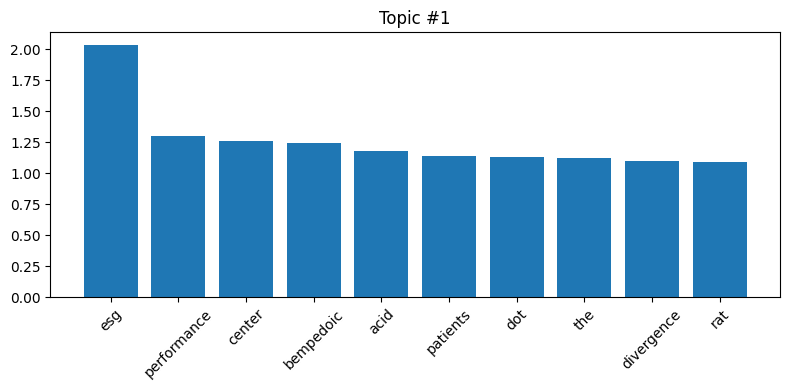

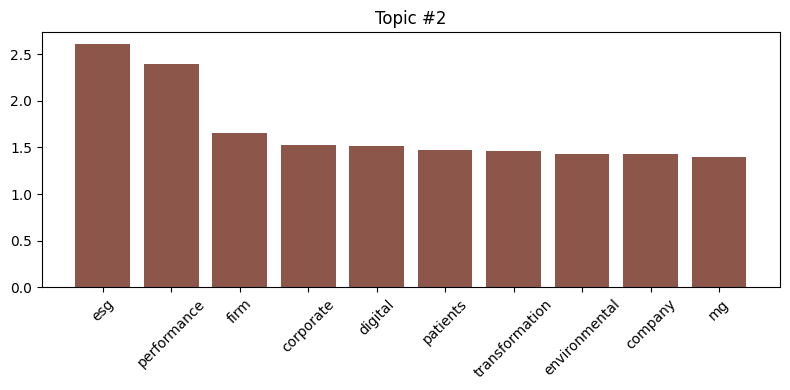

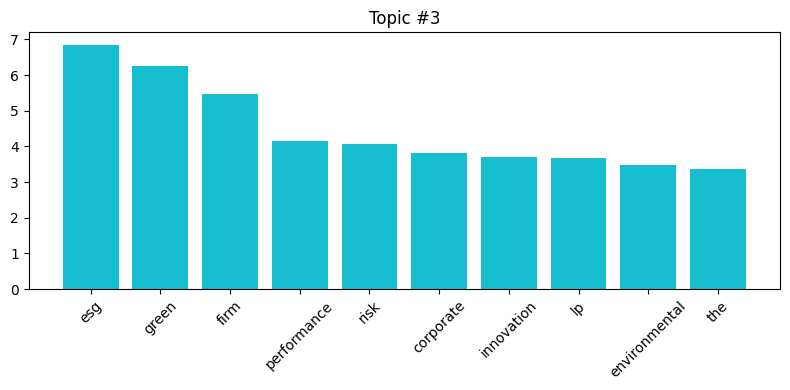

In [52]:
import matplotlib.pyplot as plt
import numpy as np

###### 각 토픽의 상위 단어와 중요도 시각화 ######

# LDA 모델 훈련 결과
# model = LatentDirichletAllocation(...)
# tf_feature_names = vectorizer.get_feature_names_out()
def plot_top_words(model, feature_names, n_top_words=10):
    num_topics = model.components_.shape[0]
    colors = plt.cm.get_cmap('tab10', num_topics)  # 최대 10개의 색상 자동 생성

    for topic_idx, topic in enumerate(model.components_):
        top_features = topic.argsort()[:-n_top_words - 1:-1]
        top_words = [feature_names[i] for i in top_features]
        weights = topic[top_features]

        plt.figure(figsize=(8, 4))
        plt.bar(top_words, weights, color=colors(topic_idx % 10))  # 색상 순환
        plt.title(f"Topic #{topic_idx + 1}")  # 1부터 시작
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

# terms는 위 코드에서 tfidf_vectorizer.get_feature_names_out()를 통해 얻은 단어 집합입니다.
# lda_model은 위 코드에서 LatentDirichletAllocation 모델 학습을 통해 얻은 모델 객체입니다.
plot_top_words(lda_model, terms)

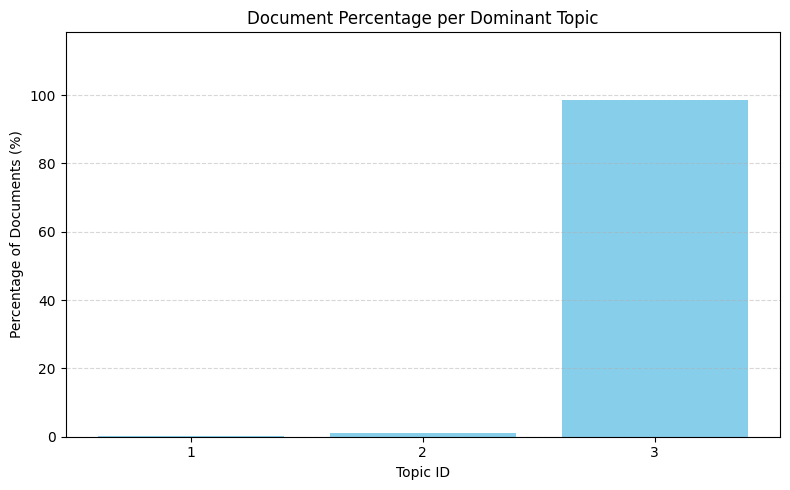

In [53]:
###### 각 토픽이 전체 문서에서 차지하는 비율 시각화 ######

# 문서별로 가장 높은 토픽 선택
topic_distribution = lda_model.transform(tfidf)
dominant_topics = np.argmax(topic_distribution, axis=1)

# 비율(%) 계산
topic_counts = np.bincount(dominant_topics, minlength=lda_model.n_components)
topic_percentages = topic_counts / topic_counts.sum() * 100  # %로 환산

# 시각화
plt.figure(figsize=(8, 5))
plt.bar(range(1, lda_model.n_components + 1), topic_percentages, color='skyblue')
plt.xlabel('Topic ID')
plt.ylabel('Percentage of Documents (%)')
plt.title('Document Percentage per Dominant Topic')
plt.xticks(range(1, lda_model.n_components + 1))  # 1번부터 시작
plt.ylim(0, max(topic_percentages) * 1.2)  # 여유 여백
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()